# Rotated MNIST results

Artifact-only analysis for Plan 5. Phase 1 contains infrastructure smoke evidence only; scientific comparisons begin after the learnability gate.

In [1]:
from pathlib import Path
import sys

repo_root = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / 'mnist_experiment' / 'plan5.md').is_file()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from mnist_experiment.rotated_mnist.analysis import (
    load_completed_audits, load_completed_phase3_runs, load_completed_phase4_runs,
    load_completed_summaries, load_transform_examples, phase3_paired_contrast,
    phase3_summary_rows, phase3_trajectory_rows, phase4_applied_contrasts,
    phase4_revisit_rows, phase4_summary_rows, phase4_trajectory_rows, summary_rows,
)

run_root = repo_root / 'cache' / 'mnist_experiment' / 'rotated_mnist' / 'runs'
audit_root = repo_root / 'cache' / 'mnist_experiment' / 'rotated_mnist' / 'audits'
phase3_root = repo_root / 'cache' / 'mnist_experiment' / 'rotated_mnist' / 'phase3'
phase4_root = repo_root / 'cache' / 'mnist_experiment' / 'rotated_mnist' / 'phase4'
runs = load_completed_summaries(run_root)
audits = tuple(audit for audit in load_completed_audits(audit_root) if 'smoke' not in audit.config.experiment)
if not audits:
    raise FileNotFoundError('No completed scientific Phase 2 audit was found')
audit = max(audits, key=lambda candidate: candidate.manifest['completed_at'])
print(audit.path)

/home/evan/Documents/notebooks/amari-chenstov-updates/cache/mnist_experiment/rotated_mnist/audits/rotated_mnist_phase2_learnability_holdout_audit__replica-0001__1a2146c38e8a2490


## Phase 2 feasibility gate

The gate compares high-data learnability and Fisher path change with independently refit endpoint noise. Euclidean parameter displacement is descriptive, not decisive.

In [2]:
gate = audit.audit_summary['gate']
display(pd.DataFrame([
    {'quantity': 'Zero-shot environmental accuracy at 30 degrees', 'value': gate['zero_shot_environment_accuracy_30']},
    {'quantity': 'High-data environmental accuracy at 30 degrees', 'value': gate['reference_environment_accuracy_30']},
    {'quantity': 'Learning room', 'value': gate['learning_room']},
    {'quantity': 'Fisher-change signal/noise', 'value': gate['fisher_change_signal_to_noise']},
]))
print('Gate recommendation:', gate['recommendation'], gate['checks'])

,quantity,value
0,Zero-shot environmental accuracy at 30 degrees,0.480312
1,High-data environmental accuracy at 30 degrees,0.888874
2,Learning room,0.408562
3,Fisher-change signal/noise,1.658620


Gate recommendation: proceed {'fisher_path_exceeds_repeat_noise': True, 'high_data_learnable': True, 'zero_shot_leaves_learning_room': True}


## Transfer and attainability

Environmental multiclass accuracy and NLL describe the all-digit rotation task. Reference models are independent high-data fits from the same upright initialization; the class-recall panel below localizes aggregate failures.

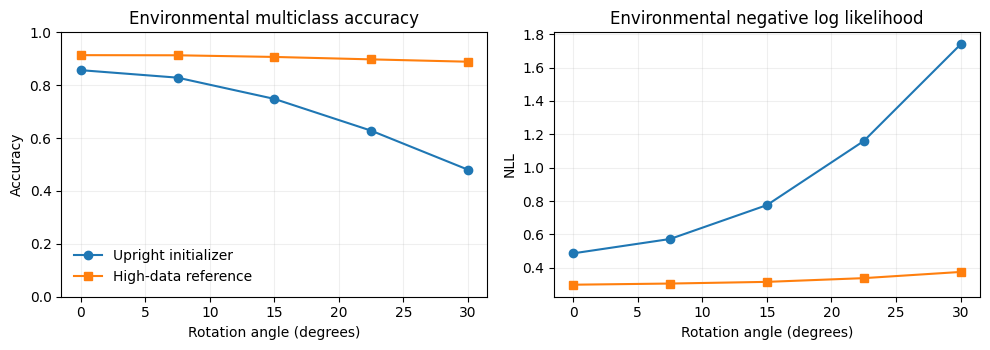

In [3]:
zero = pd.DataFrame(audit.zero_shot_metrics).sort_values('angle_degrees')
primary = pd.DataFrame([{'angle_degrees': row['angle_degrees'], **row['evaluation']} for row in audit.reference_metrics if row['role'] == 'primary']).sort_values('angle_degrees')
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharex=True)
for axis, metric, title, ylabel in zip(axes, ('environment_accuracy', 'nll'), ('Environmental multiclass accuracy', 'Environmental negative log likelihood'), ('Accuracy', 'NLL')):
    axis.plot(zero['angle_degrees'], zero[metric], marker='o', label='Upright initializer')
    axis.plot(primary['angle_degrees'], primary[metric], marker='s', label='High-data reference')
    axis.set(title=title, xlabel='Rotation angle (degrees)', ylabel=ylabel)
    if metric == 'environment_accuracy':
        axis.set_ylim(0, 1)
    axis.grid(alpha=.2)
axes[0].legend(frameon=False)
fig.tight_layout()
plt.show()

## Fisher path and refit noise

Relative Fisher change is $\lVert \widehat{\mathcal I}_{b}-\widehat{\mathcal I}_{a}\rVert_F/\lVert \widehat{\mathcal I}_{a}\rVert_F$. Endpoint crosses show the same quantity after independently refitting at a fixed angle.

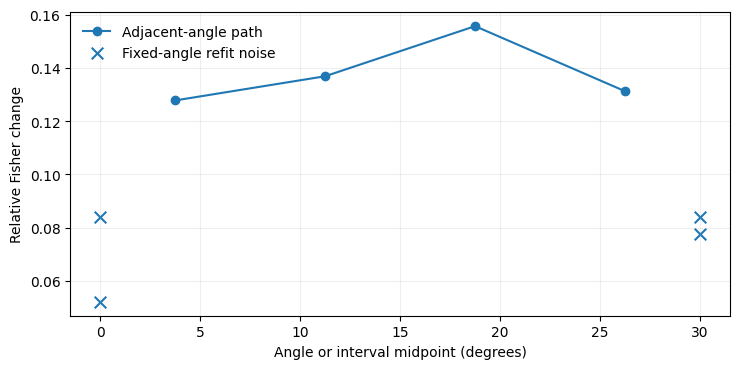

,from_angle_degrees,to_angle_degrees,euclidean_displacement,mean_fisher_quadratic,fisher_directional_asymmetry,relative_fisher_frobenius_change
0,0.0,7.5,1.644880,0.100913,0.036466,0.127780
1,7.5,15.0,1.413606,0.100037,0.051688,0.136852
2,15.0,22.5,1.410140,0.131557,0.061627,0.155660
3,22.5,30.0,1.454455,0.142439,0.024533,0.131237


In [4]:
path = pd.DataFrame(audit.path_metrics['path'])
noise = pd.DataFrame(audit.path_metrics['repeated_fit_noise'])
midpoint = .5 * (path['from_angle_degrees'] + path['to_angle_degrees'])
fig, axis = plt.subplots(figsize=(7.5, 3.8))
axis.plot(midpoint, path['relative_fisher_frobenius_change'], marker='o', label='Adjacent-angle path')
axis.scatter(noise['angle_degrees'], noise['relative_fisher_frobenius_change'], marker='x', s=70, label='Fixed-angle refit noise')
axis.set(xlabel='Angle or interval midpoint (degrees)', ylabel='Relative Fisher change')
axis.grid(alpha=.2)
axis.legend(frameon=False)
fig.tight_layout()
plt.show()
display(path[['from_angle_degrees', 'to_angle_degrees', 'euclidean_displacement', 'mean_fisher_quadratic', 'fisher_directional_asymmetry', 'relative_fisher_frobenius_change']])

## Transform audit

One fixed reporting observation per class is shown at every reference angle.

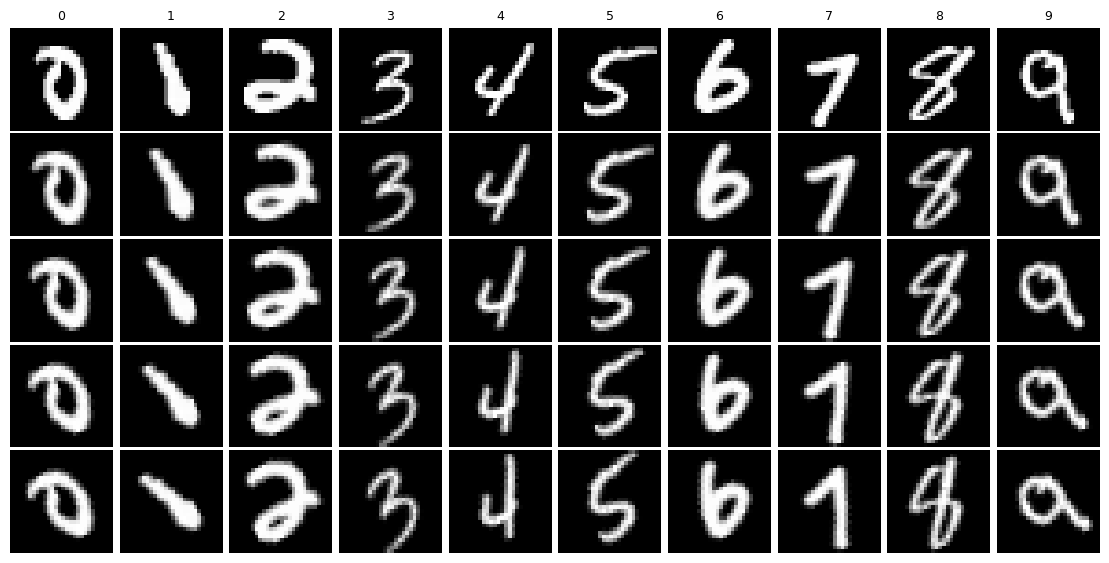

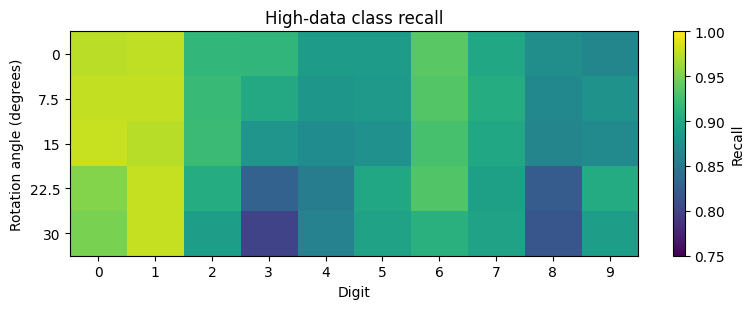

,angle_degrees,worst_class_recall
0,0.0,0.864428
1,7.5,0.867089
2,15.0,0.863291
3,22.5,0.822785
4,30.0,0.800000


In [5]:
examples = load_transform_examples(audit)
images = examples['images'].numpy()
angles = examples['angles_degrees'].tolist()
fig, axes = plt.subplots(len(angles), 10, figsize=(11, 5.5))
for row_index, angle in enumerate(angles):
    for label in range(10):
        axes[row_index, label].imshow(images[row_index, label, 0], cmap='gray', vmin=0, vmax=1)
        axes[row_index, label].axis('off')
        if row_index == 0:
            axes[row_index, label].set_title(str(label), fontsize=9)
    axes[row_index, 0].set_ylabel(f'{angle:g} deg', rotation=0, labelpad=22, va='center')
fig.tight_layout(pad=.25)
plt.show()

primary_rows = [row for row in audit.reference_metrics if row['role'] == 'primary']
class_accuracy = np.asarray([[row['confusion_matrix'][digit][digit] / sum(row['confusion_matrix'][digit]) for digit in range(10)] for row in primary_rows])
fig, axis = plt.subplots(figsize=(8, 3.2))
image = axis.imshow(class_accuracy, cmap='viridis', vmin=.75, vmax=1, aspect='auto')
axis.set(xticks=range(10), yticks=range(len(primary_rows)), yticklabels=[f"{row['angle_degrees']:g}" for row in primary_rows], xlabel='Digit', ylabel='Rotation angle (degrees)', title='High-data class recall')
fig.colorbar(image, ax=axis, label='Recall')
fig.tight_layout()
plt.show()
display(pd.DataFrame({'angle_degrees': [row['angle_degrees'] for row in primary_rows], 'worst_class_recall': class_accuracy.min(axis=1)}))

## Offline controller diagnostic

These ideal-covariance coefficients do not actuate a learner and are not evidence of predictive EDR benefit.

In [6]:
display(pd.DataFrame(audit.path_metrics['offline_risk_coefficients']))

,from_angle_degrees,idealized_new_covariance_risk,idealized_old_covariance_risk,instantaneous_unclipped_pi,q_before,signal_energy,to_angle_degrees
0,0.0,64.0,0.017067,0.001783,0.000033,0.097233,7.5
1,7.5,64.0,0.175403,0.004205,0.000343,0.094866,15.0
2,15.0,64.0,0.318301,0.007105,0.000622,0.139664,22.5
3,22.5,64.0,0.447267,0.009184,0.000874,0.145933,30.0


## Phase 3 low-data transfer pilot

One development replica compares paired current-only and fixed-$\pi=.05$ direct-EMA EWC learners over the first ascent. It is mechanism evidence, not an inferential claim.

In [7]:
phase3_runs = tuple(run for run in load_completed_phase3_runs(phase3_root) if 'smoke' not in run.config.experiment)
if not phase3_runs:
    raise FileNotFoundError('No completed scientific Phase 3 pilot was found')
phase3 = max(phase3_runs, key=lambda candidate: candidate.manifest['completed_at'])
phase3_rows = pd.DataFrame(phase3_trajectory_rows(phase3))
display(pd.DataFrame(phase3_summary_rows(phase3))[[
    'condition', 'environment_accuracy_auc', 'environment_nll_auc',
    'final_current_environment_accuracy', 'final_upright_environment_accuracy',
    'final_worst_class_recall', 'optimizer_function_evaluations',
]])
display(pd.DataFrame([phase3_paired_contrast(phase3)]))

,condition,environment_accuracy_auc,environment_nll_auc,final_current_environment_accuracy,final_upright_environment_accuracy,final_worst_class_recall,optimizer_function_evaluations
0,current_only,0.615304,6.580121,0.6539,0.6454,0.209776,909
1,ewc_fixed_pi005,0.721626,1.387881,0.6145,0.7526,0.298371,2212


,ewc_minus_current_environment_accuracy_auc,ewc_minus_current_environment_nll_auc,ewc_minus_current_final_environment_accuracy,ewc_minus_current_final_upright_accuracy
0,0.106322,-5.19224,-0.0394,0.1072


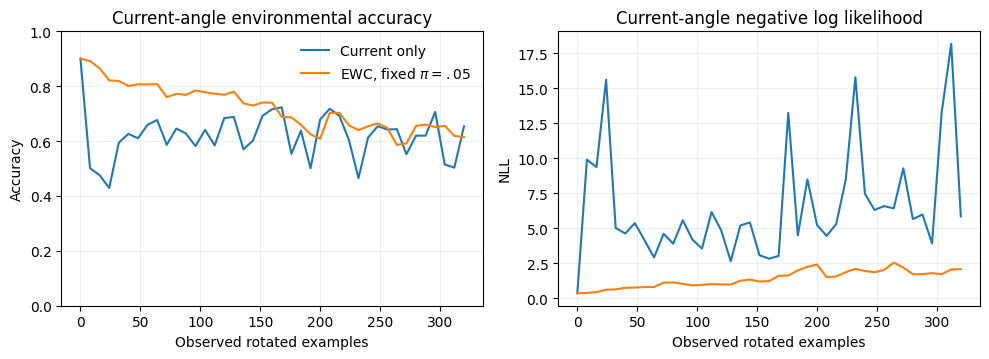

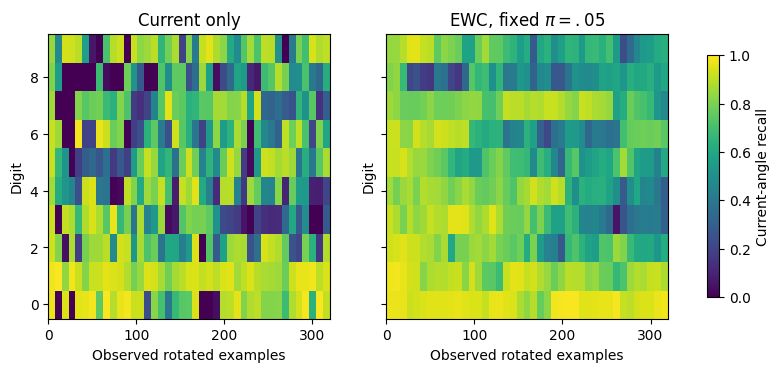

In [8]:
labels = {'current_only': 'Current only', 'ewc_fixed_pi005': r'EWC, fixed $\pi=.05$'}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), sharex=True)
for condition, group in phase3_rows.groupby('condition', sort=False):
    group = group.sort_values('observations_before_evaluation')
    axes[0].plot(group['observations_before_evaluation'], group['current_environment_accuracy'], label=labels[condition])
    axes[1].plot(group['observations_before_evaluation'], group['current_nll'], label=labels[condition])
axes[0].set(title='Current-angle environmental accuracy', ylabel='Accuracy', ylim=(0, 1))
axes[1].set(title='Current-angle negative log likelihood', ylabel='NLL')
for axis in axes:
    axis.set_xlabel('Observed rotated examples')
    axis.grid(alpha=.2)
axes[0].legend(frameon=False)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), sharex=True, sharey=True)
for axis, condition in zip(axes, phase3.config.conditions):
    group = phase3_rows[phase3_rows['condition'] == condition].sort_values('observations_before_evaluation')
    recall = np.asarray(group['current_per_class_recall'].tolist()).T
    image = axis.imshow(recall, aspect='auto', origin='lower', vmin=0, vmax=1, extent=(0, group['observations_before_evaluation'].max(), -.5, 9.5), cmap='viridis')
    axis.set(title=labels[condition], xlabel='Observed rotated examples', ylabel='Digit')
fig.colorbar(image, ax=axes, label='Current-angle recall', shrink=.85)
plt.show()

## Phase 4 repeated-path memory screen

One development replica compares current-only, fixed-$\pi=.05$ EWC, Replay B32, Hybrid B32, and fresh unbounded replay over the complete $0\to15\to30\to0\to15\to30$ degree path. The unbounded buffer is a resource-unconstrained control. These trajectories select contrasts for confirmation; they do not provide confidence intervals.

In [9]:
phase4_runs = tuple(run for run in load_completed_phase4_runs(phase4_root) if 'smoke' not in run.config.experiment)
if not phase4_runs:
    raise FileNotFoundError('No completed scientific Phase 4 memory screen was found')
phase4 = max(phase4_runs, key=lambda candidate: candidate.manifest['completed_at'])
phase4_rows = pd.DataFrame(phase4_trajectory_rows(phase4))
phase4_summary = pd.DataFrame(phase4_summary_rows(phase4))
display(phase4_summary[[
    'condition', 'environment_accuracy_auc', 'environment_nll_auc',
    'first_ascent_environment_accuracy_auc', 'second_ascent_environment_accuracy_auc',
    'final_current_environment_accuracy', 'final_upright_environment_accuracy',
]])
display(pd.DataFrame(phase4_applied_contrasts(phase4)))

,condition,environment_accuracy_auc,environment_nll_auc,first_ascent_environment_accuracy_auc,second_ascent_environment_accuracy_auc,final_current_environment_accuracy,final_upright_environment_accuracy
0,current_only,0.575089,9.478153,0.468641,0.669663,0.5947,0.5322
1,ewc_fixed_pi005,0.734675,1.184343,0.706144,0.756556,0.6365,0.7611
2,replay_b032,0.740690,6.560306,0.683699,0.786963,0.6635,0.5865
3,hybrid_b032_fixed_pi005,0.741419,1.563246,0.747587,0.734615,0.6450,0.6326
4,replay_unbounded,0.800600,5.528682,0.716846,0.865968,0.7984,0.8540


,contrast,delta_environment_accuracy_auc,delta_environment_nll_auc,delta_first_ascent_environment_accuracy_auc,delta_second_ascent_environment_accuracy_auc,delta_final_current_environment_accuracy,delta_final_upright_environment_accuracy
0,EWC - current only,0.159586,-8.293809,0.237503,0.086894,0.0418,0.2289
1,Replay B32 - current only,0.165601,-2.917847,0.215058,0.117300,0.0688,0.0543
2,Hybrid B32 - Replay B32,0.000730,-4.997060,0.063889,-0.052348,-0.0185,0.0461
3,Hybrid B32 - unbounded replay,-0.059181,-3.965436,0.030741,-0.131352,-0.1534,-0.2214


### EWC and bounded replay isolation

Each panel contains only the treatment and its direct comparator. Vertical guides mark the six schedule knots; the second $0^\circ$ point begins the matched revisit ascent.

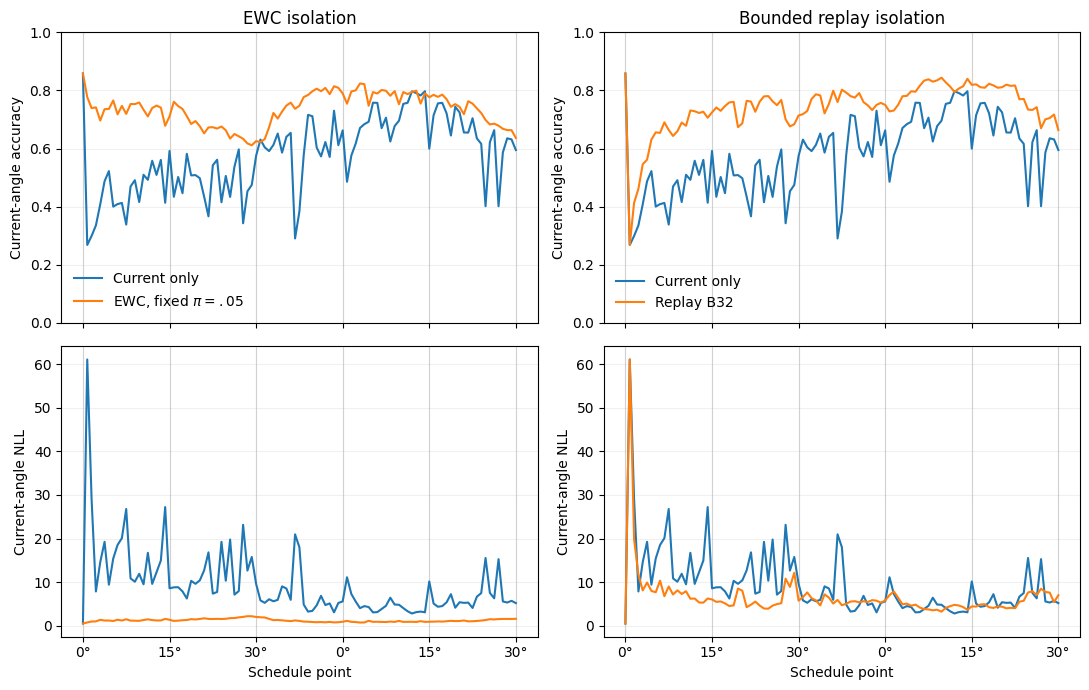

In [10]:
condition_labels = {
    'current_only': 'Current only',
    'ewc_fixed_pi005': r'EWC, fixed $\pi=.05$',
    'replay_b032': 'Replay B32',
    'hybrid_b032_fixed_pi005': r'Hybrid B32, fixed $\pi=.05$',
    'replay_unbounded': 'Unbounded replay',
}
knot_steps = np.flatnonzero(phase4_rows[phase4_rows['condition'] == 'current_only']['knot'].to_numpy())
knot_angles = phase4_rows[phase4_rows['condition'] == 'current_only'].query('knot')['angle_degrees'].to_numpy()
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
contrasts = (
    (('current_only', 'ewc_fixed_pi005'), 'EWC isolation'),
    (('current_only', 'replay_b032'), 'Bounded replay isolation'),
)
for column, (conditions, title) in enumerate(contrasts):
    for condition in conditions:
        group = phase4_rows[phase4_rows['condition'] == condition].sort_values('step')
        axes[0, column].plot(group['step'], group['current_environment_accuracy'], label=condition_labels[condition])
        axes[1, column].plot(group['step'], group['current_nll'], label=condition_labels[condition])
    axes[0, column].set(title=title, ylabel='Current-angle accuracy', ylim=(0, 1))
    axes[1, column].set(ylabel='Current-angle NLL', xlabel='Schedule point')
    axes[0, column].legend(frameon=False)
for axis in axes.flat:
    for step in knot_steps:
        axis.axvline(step, color='0.85', linewidth=.8, zorder=0)
    axis.grid(alpha=.18)
axes[1, 0].set_xticks(knot_steps, [f'{angle:g}°' for angle in knot_angles])
axes[1, 1].set_xticks(knot_steps, [f'{angle:g}°' for angle in knot_angles])
fig.tight_layout()
plt.show()

### Hybrid, replay, and revisitation

Hybrid B32 is compared with its no-EWC bounded replay counterpart and with the unbounded control. Revisit lift is the matched-angle second-ascent metric minus the first-ascent metric; common lift across treatments is additional exposure, not method-specific memory.

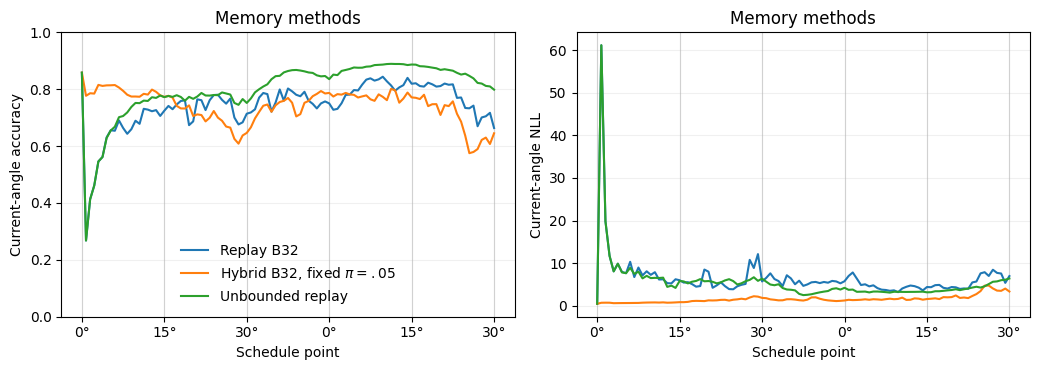

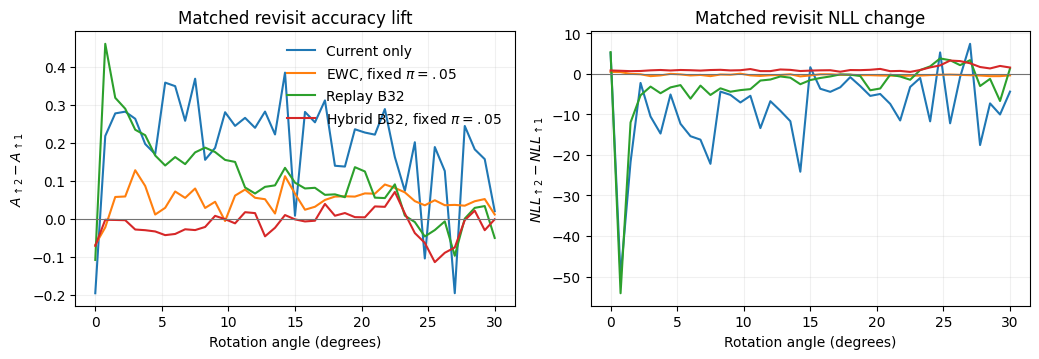

In [11]:
memory_conditions = ('replay_b032', 'hybrid_b032_fixed_pi005', 'replay_unbounded')
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), sharex=True)
for condition in memory_conditions:
    group = phase4_rows[phase4_rows['condition'] == condition].sort_values('step')
    axes[0].plot(group['step'], group['current_environment_accuracy'], label=condition_labels[condition])
    axes[1].plot(group['step'], group['current_nll'], label=condition_labels[condition])
axes[0].set(title='Memory methods', ylabel='Current-angle accuracy', ylim=(0, 1))
axes[1].set(title='Memory methods', ylabel='Current-angle NLL')
for axis in axes:
    axis.set(xlabel='Schedule point', xticks=knot_steps, xticklabels=[f'{angle:g}°' for angle in knot_angles])
    for step in knot_steps:
        axis.axvline(step, color='0.85', linewidth=.8, zorder=0)
    axis.grid(alpha=.18)
axes[0].legend(frameon=False)
fig.tight_layout()
plt.show()

revisit = pd.DataFrame(phase4_revisit_rows(phase4))
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.7), sharex=True)
for condition in ('current_only', 'ewc_fixed_pi005', 'replay_b032', 'hybrid_b032_fixed_pi005'):
    group = revisit[revisit['condition'] == condition].sort_values('angle_degrees')
    axes[0].plot(group['angle_degrees'], group['environment_accuracy_revisit_lift'], label=condition_labels[condition])
    axes[1].plot(group['angle_degrees'], group['environment_nll_revisit_change'], label=condition_labels[condition])
axes[0].set(title='Matched revisit accuracy lift', ylabel=r'$A_{\uparrow2}-A_{\uparrow1}$')
axes[1].set(title='Matched revisit NLL change', ylabel=r'$NLL_{\uparrow2}-NLL_{\uparrow1}$')
for axis in axes:
    axis.axhline(0, color='0.45', linewidth=.8)
    axis.set(xlabel='Rotation angle (degrees)')
    axis.grid(alpha=.18)
axes[0].legend(frameon=False)
fig.tight_layout()
plt.show()

### Realized resource ledger

Logical replay bytes account for each exact transformed float32 observation even though the experimental harness retrieves it from the immutable shared stream tensor. This prevents paired execution from creating a fictional storage advantage.

In [12]:
display(phase4_summary[[
    'condition', 'optimizer_function_evaluations', 'optimizer_event_evaluations',
    'archive_optimizer_event_evaluations', 'learner_optimization_wall_time_seconds',
    'fisher_update_wall_time_seconds', 'archive_consolidation_wall_time_seconds',
    'logical_replay_persistent_bytes_final', 'fisher_summary_bytes_final',
    'archive_summary_bytes_final', 'replay_event_count_final',
]])

,condition,optimizer_function_evaluations,optimizer_event_evaluations,archive_optimizer_event_evaluations,learner_optimization_wall_time_seconds,fisher_update_wall_time_seconds,archive_consolidation_wall_time_seconds,logical_replay_persistent_bytes_final,fisher_summary_bytes_final,archive_summary_bytes_final,replay_event_count_final
0,current_only,2399,19192,0,8.954134,0.000000,0.000000,0,0,0,0
1,ewc_fixed_pi005,5557,44456,0,24.726818,0.889976,0.000000,0,36864,0,0
2,replay_b032,3188,124816,0,12.596910,0.000000,0.000000,102168,0,0,32
3,hybrid_b032_fixed_pi005,5446,213576,41328,24.731016,0.000000,23.699074,102168,0,20480,32
4,replay_unbounded,4795,1982144,0,21.714329,0.000000,0.000000,2553624,0,0,800


## Interpretation guard

Phase 2 establishes learnability and geometric signal. Phases 3 and 4 are paired development replicas: they can promote mechanisms and practical contrasts, but cannot establish statistical significance or adaptive-composition benefit.